Ethan Ho
017157582
CMPE 188

In [188]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score,roc_curve
import seaborn as sns

In [168]:
startup_data = pd.read_csv("E:/vs/school/CMPE_188/data/StartupFailure.csv")
startup_data.head()

,Name,Sector,Years of Operation,What They Did,How Much They Raised,Why They Failed,Takeaway,Giants,No Budget,Competition,Poor Market Fit,Acquisition Stagnation,Platform Dependency,Monetization Failure,Niche Limits,Execution Flaws,Trend Shifts,Toxicity/Trust Issues,Regulatory Pressure,Overhype
0,Avant,Finance and Insurance,2012-2023,Online personal loans,$655M,Lost to LendingClub and high defaults,Lending needs risk balance,1,1,1,0,0,0,0,0,0,0,0,0,0.0
1,Bitpass,Finance and Insurance,2002-2008,Micropayments platform,$2M,Lost to PayPal and low adoption,Micropayments need mass use,1,0,1,1,0,0,0,0,0,0,0,0,0.0
2,Cake Financial,Finance and Insurance,2006-2011,Portfolio tracking tool,$3M,Lost to Mint and sold to TradeKing,Finance tools need scale,1,0,1,0,1,0,0,0,0,0,0,0,0.0
3,Circle,Finance and Insurance,2013-2023,Crypto payments and stablecoin,$500M,Lost to Coinbase and market shifts,Crypto needs stability,1,0,1,0,0,0,0,0,0,1,0,0,0.0
4,Clarity Money,Finance and Insurance,2016-2022,Personal finance app,$11M,Lost to Mint/Acorns and sold to Goldman,Finance apps need edge,1,0,1,0,1,0,0,0,0,0,0,0,0.0


In [169]:
startup_data.describe()

,Giants,No Budget,Competition,Poor Market Fit,Acquisition Stagnation,Platform Dependency,Monetization Failure,Niche Limits,Execution Flaws,Trend Shifts,Toxicity/Trust Issues,Regulatory Pressure,Overhype
count,47.000000,47.000000,47.0,47.000000,47.000000,47.0,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,46.000000
mean,0.957447,0.063830,1.0,0.234043,0.255319,0.0,0.021277,0.191489,0.063830,0.042553,0.063830,0.063830,0.021739
std,0.204030,0.247092,0.0,0.427976,0.440755,0.0,0.145865,0.397727,0.247092,0.204030,0.247092,0.247092,0.147442
min,0.000000,0.000000,1.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,1.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,1.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.0,0.000000,0.500000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.0,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [170]:
startup_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Name                    47 non-null     object 
 1   Sector                  47 non-null     object 
 2   Years of Operation      47 non-null     object 
 3   What They Did           47 non-null     object 
 4   How Much They Raised    47 non-null     object 
 5   Why They Failed         47 non-null     object 
 6   Takeaway                47 non-null     object 
 7   Giants                  47 non-null     int64  
 8   No Budget               47 non-null     int64  
 9   Competition             47 non-null     int64  
 10  Poor Market Fit         47 non-null     int64  
 11  Acquisition Stagnation  47 non-null     int64  
 12  Platform Dependency     47 non-null     int64  
 13  Monetization Failure    47 non-null     int64  
 14  Niche Limits            47 non-null     int6

I decided to remove the `Name` coloum as it has no relavance and the sector column because all the companies in the dataset were in the same sector. For the `How Much They Raised` column, I filtered out the integer and kept it for the column. The `Years of Operation` I decided to just subtract the ending year by the starting to turn it into a numerical column as well. The rest of the categorical data I decided to encode and figure out if they were correlated. I then removed `Competition` and `Platform Dependency` as they were all the same. `Overhyped` also has a single NaN row so I removed it.

In [171]:
df = startup_data.drop(["Name", "Sector", "Competition", "Platform Dependency"], axis=1)

# Extracted the regex for any number of decimal numbers for the col
df["How Much They Raised"] = df["How Much They Raised"].str.extract('(\d+)', expand=False).astype(int)

# Subtracted the ending year by the starting
df["Years of Operation"] = (df["Years of Operation"].apply((lambda x: int(x.split("-")[1]) - int(x.split("-")[0]))))

df.dropna()

df.head()

<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Admin\AppData\Local\Temp\ipykernel_6740\2443238793.py:4: SyntaxWarning: invalid escape sequence '\d'
  df["How Much They Raised"] = df["How Much They Raised"].str.extract('(\d+)', expand=False).astype(int)


,Years of Operation,What They Did,How Much They Raised,Why They Failed,Takeaway,Giants,No Budget,Poor Market Fit,Acquisition Stagnation,Monetization Failure,Niche Limits,Execution Flaws,Trend Shifts,Toxicity/Trust Issues,Regulatory Pressure,Overhype
0,11,Online personal loans,655,Lost to LendingClub and high defaults,Lending needs risk balance,1,1,0,0,0,0,0,0,0,0,0.0
1,6,Micropayments platform,2,Lost to PayPal and low adoption,Micropayments need mass use,1,0,1,0,0,0,0,0,0,0,0.0
2,5,Portfolio tracking tool,3,Lost to Mint and sold to TradeKing,Finance tools need scale,1,0,0,1,0,0,0,0,0,0,0.0
3,10,Crypto payments and stablecoin,500,Lost to Coinbase and market shifts,Crypto needs stability,1,0,0,0,0,0,0,1,0,0,0.0
4,6,Personal finance app,11,Lost to Mint/Acorns and sold to Goldman,Finance apps need edge,1,0,0,1,0,0,0,0,0,0,0.0


In [172]:
encoder = LabelEncoder()

df["What They Did"] = encoder.fit_transform(df["What They Did"])
df["Why They Failed"] = encoder.fit_transform(df["Why They Failed"])
df["Takeaway"] = encoder.fit_transform(df["Takeaway"])

df.head()

,Years of Operation,What They Did,How Much They Raised,Why They Failed,Takeaway,Giants,No Budget,Poor Market Fit,Acquisition Stagnation,Monetization Failure,Niche Limits,Execution Flaws,Trend Shifts,Toxicity/Trust Issues,Regulatory Pressure,Overhype
0,11,26,655,20,18,1,1,0,0,0,0,0,0,0,0,0.0
1,6,20,2,28,22,1,0,1,0,0,0,0,0,0,0,0.0
2,5,34,3,23,14,1,0,0,1,0,0,0,0,0,0,0.0
3,10,9,500,9,6,1,0,0,0,0,0,0,1,0,0,0.0
4,6,32,11,24,11,1,0,0,1,0,0,0,0,0,0,0.0


In [173]:
df.describe()

,Years of Operation,What They Did,How Much They Raised,Why They Failed,Takeaway,Giants,No Budget,Poor Market Fit,Acquisition Stagnation,Monetization Failure,Niche Limits,Execution Flaws,Trend Shifts,Toxicity/Trust Issues,Regulatory Pressure,Overhype
count,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,46.000000
mean,7.595745,22.425532,80.340426,22.787234,22.702128,0.957447,0.063830,0.234043,0.255319,0.021277,0.191489,0.063830,0.042553,0.063830,0.063830,0.021739
std,3.261499,13.006261,162.597031,13.421165,13.348042,0.204030,0.247092,0.427976,0.440755,0.145865,0.397727,0.247092,0.204030,0.247092,0.247092,0.147442
min,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,11.500000,2.000000,11.500000,11.500000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,6.000000,23.000000,10.000000,23.000000,23.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,10.500000,32.500000,68.500000,34.500000,33.500000,1.000000,0.000000,0.000000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,15.000000,44.000000,689.000000,45.000000,45.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


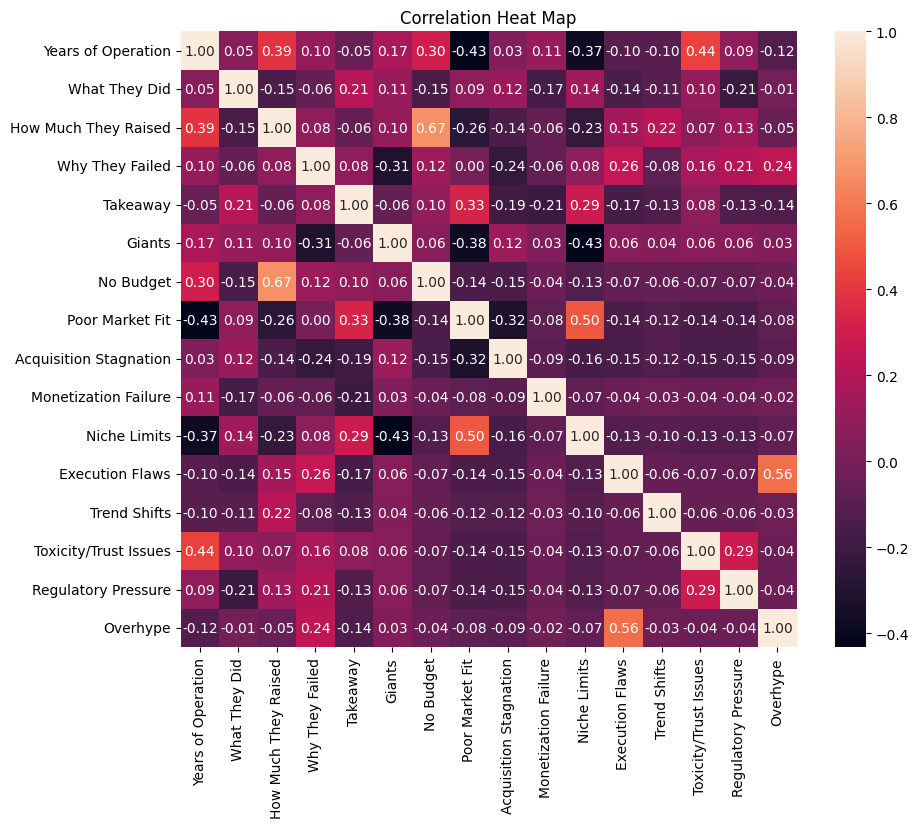

In [174]:
plt.figure(figsize=(10,8))
corr_map = df.corr("pearson")
sns.heatmap(corr_map, square=True, annot=True, fmt='.2f')
plt.title("Correlation Heat Map")
plt.show()

After encoding the three categoical coloumns did not seem to have too much correlation, especially the `What They Did` but I decided to keep them and let the trees decide.

### Splitting Data

I decided to have `Why They Failed` as the output so that the model can try to predict some of the common reasons a company might fail.

In [175]:
x = df.drop(["Why They Failed"], axis=1)
y = pd.DataFrame(df["Why They Failed"])

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20)

print(y_train.head())
print(x_train.head())

    Why They Failed
0                20
1                28
36               18
3                 9
23                7
    Years of Operation  What They Did  How Much They Raised  Takeaway  Giants  \
0                   11             26                   655        18       1   
1                    6             20                     2        22       1   
36                   6             17                    20        16       1   
3                   10              9                   500         6       1   
23                  15             36                    20        36       1   

    No Budget  Poor Market Fit  Acquisition Stagnation  Monetization Failure  \
0           1                0                       0                     0   
1           0                1                       0                     0   
36          0                0                       0                     0   
3           0                0                       0                   

### Trees

In [ ]:
# Decision Tree
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(x_train, y_train)
decision_tree_predict = decision_tree.predict(x_test)
print("Decision Tree Score: ", accuracy_score(y_test, decision_tree_predict))

# Bagging Classifier
bagging_tree = BaggingClassifier(
    DecisionTreeClassifier(random_state=42),
    # n_estimators=500,
    # max_samples=100,
    # bootstrap=True,
    # n_jobs=-1,
    random_state=42
    )
bagging_tree.fit(x_train, y_train)
bagging_tree_predict = bagging_tree.predict(x_test)
print("Decision Tree Score: ", accuracy_score(y_test, bagging_tree_predict))

# Random Forrest
random_forrest = RandomForestClassifier(
    # n_estimators=500, 
    # max_leaf_nodes=16, 
    # n_jobs=-1, 
    random_state=42)
random_forrest.fit(x_train, y_train)
random_forrest_predict = random_forrest.predict(x_test)
random_forrest_prob = random_forrest.predict_proba(x_test)
print("Decision Tree Score: ", accuracy_score(y_test, random_forrest_predict))


Decision Tree Score:  0.0
Decision Tree Score:  0.0
Decision Tree Score:  0.0


c:\Users\Admin\anaconda3\envs\cmpe188\Lib\site-packages\sklearn\ensemble\_bagging.py:878: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Admin\anaconda3\envs\cmpe188\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [189]:
# Random Forrest ROC Curve

random_forrest_score = random_forrest_prob[:,1]
fpr_rf,tpr_rf, threshold_rf = roc_curve(y_test, random_forrest_score)

def plot_roc_curve(fpr, tpr, lable=None):
    plt.plot(fpr,tpr, linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.axis([0, 1, 0, 1])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    
plot_roc_curve(fpr_rf,tpr_rf)
plt.legend(loc="bottom right")
plt.show()

ValueError: multiclass format is not supported